In [1]:
%pip install --upgrade pip setuptools wheel
%pip install --no-binaxry :all: sqlalchemy psycopg2-binary
%pip install "SQLAlchemy==2.0.41" --no-binary :all: --no-build-isolation --no-deps
%pip install psycopg
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

Note: you may need to restart the kernel to use updated packages.

[optparse.groups]Usage:[/]   
  /Users/sankalpyadava/PyCharmMiscProject/.venv/bin/python -m pip install \[options] <requirement specifier> \[package-index-options] ...
  /Users/sankalpyadava/PyCharmMiscProject/.venv/bin/python -m pip install \[options] -r <requirements file> \[package-index-options] ...
  /Users/sankalpyadava/PyCharmMiscProject/.venv/bin/python -m pip install \[options] [-e] <vcs project url> ...
  /Users/sankalpyadava/PyCharmMiscProject/.venv/bin/python -m pip install \[options] [-e] <local project path> ...
  /Users/sankalpyadava/PyCharmMiscProject/.venv/bin/python -m pip install \[options] <archive url/path> ...

no such option: --no-binaxry
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
path = "/Users/sankalpyadava/Desktop/va_adult_activity_location_assignment_day.csv-10-of-160"
Adult_Activity_Location = pd.read_csv(path)
Adult_Activity_Location.drop_duplicates(inplace=True)
Adult_Activity_Location.head()

,hid,pid,activity_number,activity_type,start_time,duration,lid,longitude,latitude,travel_mode,distance
0,159884041,361729913,0,1,187200,19080,1125084195,-79.706357,37.233933,-1,0.00000
1,159884041,361729913,2,4,206580,420,2481921,-79.733418,37.207809,-1,3.76554
2,159884041,361729913,4,3,207240,1560,1477904,-79.703815,37.251894,-1,5.55870
3,159884041,361729913,6,1,209040,16200,1125084195,-79.706357,37.233933,-1,2.00984
4,159884041,361729913,8,3,226680,780,1477904,-79.703815,37.251894,-1,2.00984


In [3]:
DistancePerPerson = Adult_Activity_Location.groupby('pid')['distance'].sum().reset_index(name='total_distance')
DistancePerPerson.head()

,pid,total_distance
0,361729913,23.02084
1,361729914,25.16354
2,361729915,4.27520
3,361729916,7.35645
4,361729917,7.94915


In [4]:
NumVisits = Adult_Activity_Location.groupby(['lid', 'longitude', 'latitude']).size().reset_index(name='num_visits')
NumVisits.head()

,lid,longitude,latitude,num_visits
0,103032,-81.617617,30.309072,1
1,136048,-84.380977,33.926421,1
2,137357,-84.190482,34.018878,1
3,137378,-84.432916,33.659394,1
4,192401,-76.951317,38.647861,1


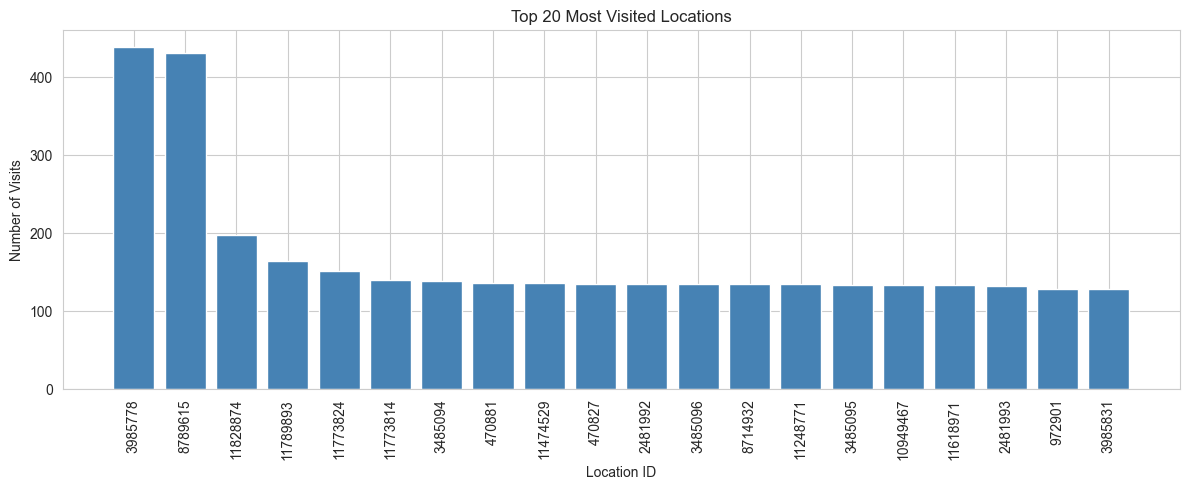

In [5]:
top20 = NumVisits.nlargest(20, 'num_visits')
plt.figure(figsize=(12, 5))
plt.bar(top20['lid'].astype(str), top20['num_visits'], color='steelblue')
plt.xticks(rotation=90)
plt.xlabel('Location ID')
plt.ylabel('Number of Visits')
plt.title('Top 20 Most Visited Locations')
plt.tight_layout()
plt.show()

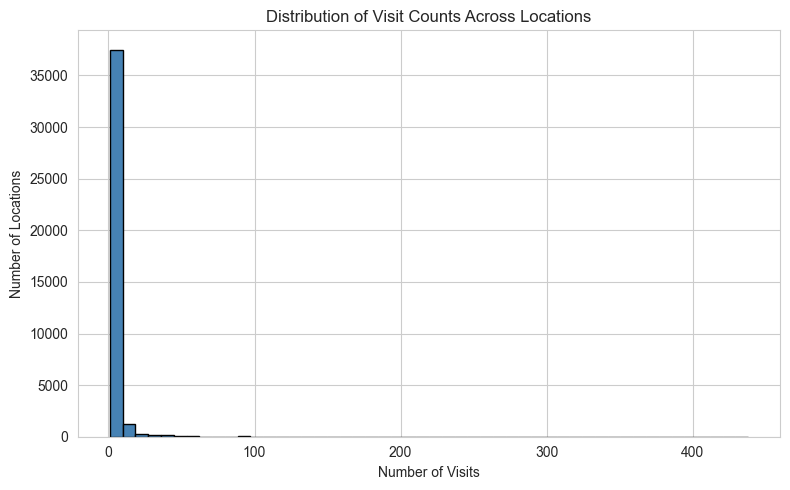

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(NumVisits['num_visits'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Number of Visits')
plt.ylabel('Number of Locations')
plt.title('Distribution of Visit Counts Across Locations')
plt.tight_layout()
plt.show()

In [7]:
m = folium.Map(location=[37.5, -79.0], zoom_start=7)
heat_data = NumVisits[['latitude', 'longitude', 'num_visits']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, max_zoom=13).add_to(m)
m

In [8]:
path2 = "/Users/sankalpyadava/Desktop/Va_location_mapping_with_NAICS.csv"
naics = pd.read_csv(path2)
naics.drop_duplicates(inplace=True)
naics.head()

,source_id,latitude,longitude,mapped_advan_id_store,designation,naics_code,naics2,naics4
0,8793639,38.312266,-77.504701,1739587.0,none,336111.0,33,3361.0
1,3499190,37.040129,-76.340238,NaN,none,NaN,na,NaN
2,10733383,36.789260,-76.111597,NaN,none:medical,NaN,na,NaN
3,8733585,38.149835,-79.071284,NaN,none,NaN,na,NaN
4,4001119,36.863998,-76.396332,NaN,none:retail,NaN,na,NaN


In [17]:
Combined = Adult_Activity_Location.merge(naics, left_on='lid', right_on='source_id', how='inner')
Combined.drop_duplicates(inplace=True)
Combined.head()

,hid,pid,activity_number,activity_type,start_time,duration,lid,longitude_x,latitude_x,travel_mode,distance,source_id,latitude_y,longitude_y,mapped_advan_id_store,designation,naics_code,naics2,naics4
0,159884041,361729913,2,4,206580,420,2481921,-79.733418,37.207809,-1,3.76554,2481921,37.207809,-79.733418,NaN,none,NaN,na,NaN
1,159884041,361729913,4,3,207240,1560,1477904,-79.703815,37.251894,-1,5.55870,1477904,37.251894,-79.703815,NaN,none:retail,NaN,na,NaN
2,159884041,361729913,8,3,226680,780,1477904,-79.703815,37.251894,-1,2.00984,1477904,37.251894,-79.703815,NaN,none:retail,NaN,na,NaN
3,159884041,361729913,12,4,234600,3600,11659996,-79.748171,37.224978,-1,3.83354,11659996,37.224979,-79.748171,NaN,none:medical,NaN,na,NaN
4,159884041,361729914,2,4,206580,420,3485043,-79.734820,37.204873,-1,4.09799,3485043,37.204873,-79.734820,NaN,none,NaN,na,NaN


In [18]:
NumVisits2 = Combined.groupby(['lid','latitude', 'longitude', 'naics_code']).size().reset_index(name='num_visits')
NumVisits2.head()
NumVisits2.to_csv("/Users/sankalpyadava/Desktop/NumVisits2.csv", index=False)

KeyError: 'latitude'

In [11]:
m2 = folium.Map(location=[37.5, -79.0], zoom_start=7)
heat_data = NumVisits2[['latitude', 'longitude', 'num_visits']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, max_zoom=13).add_to(m)
m2

NameError: name 'NumVisits2' is not defined

In [12]:
naics_visits = NumVisits2.groupby('naics_code')['num_visits'].sum().nlargest(15).reset_index()
plt.figure(figsize=(12, 5))
plt.bar(naics_visits['naics_code'].astype(str), naics_visits['num_visits'], color='coral')
plt.xticks(rotation=90)
plt.xlabel('NAICS Code')
plt.ylabel('Total Visits')
plt.title('Total Visits by NAICS Code (Top 15)')
plt.tight_layout()
plt.show()

NameError: name 'NumVisits2' is not defined